Step 1 – Install and Import Libraries

In [4]:
!pip install pyspark

In [5]:
import pandas as pd
import random
import time
from datetime import datetime
from pyspark.sql import SparkSession

Step 2 – Create Spark Session

In [6]:
spark = SparkSession.builder.appName("RealTimeLogProcessing").getOrCreate()

Step 3 – Create Log Data Generator

In [2]:
# Step 3 - Create Improved Log Data Generator

pages = [
    "/",
    "/products",
    "/cart",
    "/checkout",
    "/login",
    "/contact"
]

status_codes = [
    200, 200, 200, 200,
    201,
    400,
    404,
    500
]

def generate_log():

    return {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ip_address": f"192.168.1.{random.randint(1, 254)}",
        "endpoint": random.choice(pages),
        "status_code": random.choice(status_codes),
        "response_time_ms": random.randint(50, 1500)
    }

Step 4 – Simulate Streaming Log Data

In [7]:
## Step 4 - Generate Log Data

logs = []

for i in range(100):

    log = generate_log()

    logs.append(log)

    print("New Log:", log)

    time.sleep(0.1)

New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.223', 'endpoint': '/contact', 'status_code': 400, 'response_time_ms': 358}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.162', 'endpoint': '/', 'status_code': 200, 'response_time_ms': 778}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.91', 'endpoint': '/login', 'status_code': 200, 'response_time_ms': 772}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.244', 'endpoint': '/cart', 'status_code': 201, 'response_time_ms': 926}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.82', 'endpoint': '/cart', 'status_code': 400, 'response_time_ms': 305}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.114', 'endpoint': '/contact', 'status_code': 201, 'response_time_ms': 1476}
New Log: {'timestamp': '2026-09-28 19:48:51', 'ip_address': '192.168.1.28', 'endpoint': '/cart', 'status_code': 201, 'response_time_ms': 251

In [8]:
# Step 5 - Create Pandas DataFrame

logs_df = pd.DataFrame(logs)

logs_df.head()

,timestamp,ip_address,endpoint,status_code,response_time_ms
0,2026-09-28 19:48:51,192.168.1.223,/contact,400,358
1,2026-09-28 19:48:51,192.168.1.162,/,200,778
2,2026-09-28 19:48:51,192.168.1.91,/login,200,772
3,2026-09-28 19:48:51,192.168.1.244,/cart,201,926
4,2026-09-28 19:48:51,192.168.1.82,/cart,400,305


In [9]:
# Step 6 - Create PySpark DataFrame

spark_df = spark.createDataFrame(logs)

spark_df.show(10)

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
| /contact|192.168.1.223|             358|        400|2026-09-28 19:48:51|
|        /|192.168.1.162|             778|        200|2026-09-28 19:48:51|
|   /login| 192.168.1.91|             772|        200|2026-09-28 19:48:51|
|    /cart|192.168.1.244|             926|        201|2026-09-28 19:48:51|
|    /cart| 192.168.1.82|             305|        400|2026-09-28 19:48:51|
| /contact|192.168.1.114|            1476|        201|2026-09-28 19:48:51|
|    /cart| 192.168.1.28|             251|        201|2026-09-28 19:48:51|
|/checkout|192.168.1.244|             266|        500|2026-09-28 19:48:52|
|/products|192.168.1.174|             722|        400|2026-09-28 19:48:52|
|/products| 192.168.1.27|             225|        404|2026-09-28 19:48:52|
+---------+-------------+

In [10]:
# Step 7 - Basic Request Analytics

from pyspark.sql.functions import count, when, col

total_requests = spark_df.count()

successful_requests = spark_df.filter(
    col("status_code").isin(200, 201)
).count()

error_requests = spark_df.filter(
    col("status_code") >= 400
).count()

error_rate = (error_requests / total_requests) * 100

print("Total Requests:", total_requests)
print("Successful Requests:", successful_requests)
print("Error Requests:", error_requests)
print("Error Rate:", round(error_rate, 2), "%")

Total Requests: 100
Successful Requests: 65
Error Requests: 35
Error Rate: 35.0 %


In [11]:
# Step 8 - Requests by Endpoint

endpoint_requests = (
    spark_df
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
)

endpoint_requests.show()

+---------+-----+
| endpoint|count|
+---------+-----+
|/products|   23|
|/checkout|   20|
|    /cart|   18|
| /contact|   16|
|   /login|   12|
|        /|   11|
+---------+-----+



In [12]:
# Step 9 - Error Analysis by Endpoint

error_by_endpoint = (
    spark_df
    .filter(col("status_code") >= 400)
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
)

error_by_endpoint.show()

+---------+-----+
| endpoint|count|
+---------+-----+
|/checkout|    7|
|        /|    7|
|    /cart|    6|
|/products|    6|
|   /login|    5|
| /contact|    4|
+---------+-----+



In [13]:
# Step 10 - Status Code Analysis

status_analysis = (
    spark_df
    .groupBy("status_code")
    .count()
    .orderBy("status_code")
)

status_analysis.show()

+-----------+-----+
|status_code|count|
+-----------+-----+
|        200|   51|
|        201|   14|
|        400|   11|
|        404|   10|
|        500|   14|
+-----------+-----+



In [14]:
# Step 11 - Response Time Analysis

from pyspark.sql.functions import avg, max, min

response_time_stats = spark_df.select(
    avg("response_time_ms").alias("average_response_time"),
    max("response_time_ms").alias("maximum_response_time"),
    min("response_time_ms").alias("minimum_response_time")
)

response_time_stats.show()

+---------------------+---------------------+---------------------+
|average_response_time|maximum_response_time|minimum_response_time|
+---------------------+---------------------+---------------------+
|               751.21|                 1476|                   58|
+---------------------+---------------------+---------------------+



In [15]:
# Step 12 - Detect Slow Requests

slow_requests = (
    spark_df
    .filter(col("response_time_ms") > 1000)
    .orderBy(col("response_time_ms").desc())
)

slow_requests.show()

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
| /contact|192.168.1.114|            1476|        201|2026-09-28 19:48:51|
|    /cart|192.168.1.220|            1463|        200|2026-09-28 19:48:58|
|   /login|192.168.1.153|            1458|        200|2026-09-28 19:48:56|
|   /login| 192.168.1.41|            1432|        200|2026-09-28 19:48:53|
|/products| 192.168.1.27|            1427|        200|2026-09-28 19:48:59|
|   /login|192.168.1.112|            1420|        200|2026-09-28 19:48:55|
|        /|192.168.1.175|            1418|        404|2026-09-28 19:48:54|
|/products|192.168.1.146|            1416|        200|2026-09-28 19:48:54|
|/checkout| 192.168.1.30|            1416|        200|2026-09-28 19:48:54|
|/checkout|192.168.1.118|            1407|        200|2026-09-28 19:48:56|
|/checkout|192.168.1.233|

In [16]:
# Step 13 - Anomaly Detection

anomalies = (
    spark_df
    .filter(
        (col("response_time_ms") > 1000) |
        (col("status_code") == 500)
    )
    .orderBy(col("response_time_ms").desc())
)

anomalies.show()

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
| /contact|192.168.1.114|            1476|        201|2026-09-28 19:48:51|
|    /cart|192.168.1.220|            1463|        200|2026-09-28 19:48:58|
|   /login|192.168.1.153|            1458|        200|2026-09-28 19:48:56|
|   /login| 192.168.1.41|            1432|        200|2026-09-28 19:48:53|
|/products| 192.168.1.27|            1427|        200|2026-09-28 19:48:59|
|   /login|192.168.1.112|            1420|        200|2026-09-28 19:48:55|
|        /|192.168.1.175|            1418|        404|2026-09-28 19:48:54|
|/products|192.168.1.146|            1416|        200|2026-09-28 19:48:54|
|/checkout| 192.168.1.30|            1416|        200|2026-09-28 19:48:54|
|/checkout|192.168.1.118|            1407|        200|2026-09-28 19:48:56|
|/checkout|192.168.1.233|

In [17]:
# Step 14 - Count Detected Anomalies

anomaly_count = anomalies.count()

print("Total Anomalies Detected:", anomaly_count)

Total Anomalies Detected: 44


In [18]:
# Step 15 - Save Processed Logs

output_df = spark_df.toPandas()

output_df.to_csv("processed_logs.csv", index=False)

print("Processed logs saved successfully!")

Processed logs saved successfully!


In [19]:
# Step 16 - Save Detected Anomalies

anomalies.toPandas().to_csv("detected_anomalies.csv", index=False)

print("Anomaly results saved successfully!")

Anomaly results saved successfully!


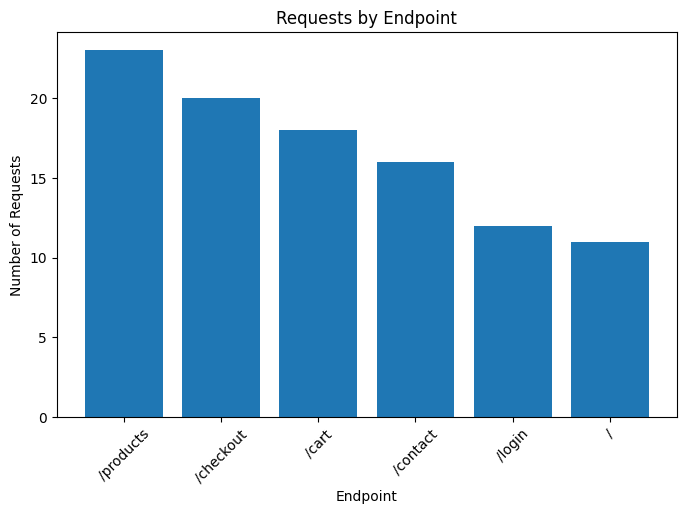

In [20]:
# Step 17 - Requests by Endpoint Visualization

import matplotlib.pyplot as plt

endpoint_data = (
    spark_df
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(endpoint_data["endpoint"], endpoint_data["count"])
plt.xlabel("Endpoint")
plt.ylabel("Number of Requests")
plt.title("Requests by Endpoint")
plt.xticks(rotation=45)
plt.show()

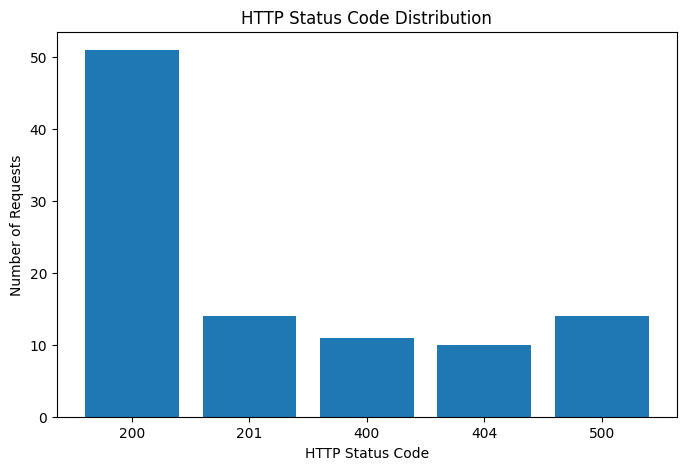

In [21]:
# Step 18 - HTTP Status Distribution

status_data = (
    spark_df
    .groupBy("status_code")
    .count()
    .orderBy("status_code")
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    status_data["status_code"].astype(str),
    status_data["count"]
)
plt.xlabel("HTTP Status Code")
plt.ylabel("Number of Requests")
plt.title("HTTP Status Code Distribution")
plt.show()

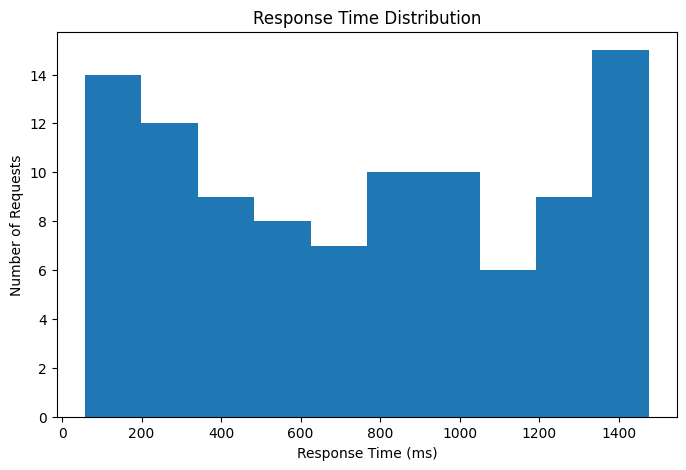

In [22]:
# Step 19 - Response Time Distribution

response_data = spark_df.select(
    "response_time_ms"
).toPandas()

plt.figure(figsize=(8, 5))
plt.hist(response_data["response_time_ms"], bins=10)
plt.xlabel("Response Time (ms)")
plt.ylabel("Number of Requests")
plt.title("Response Time Distribution")
plt.show()

In [23]:
# Step 20 - Explain Anomalies

from pyspark.sql.functions import when

anomalies_with_reason = (
    spark_df
    .filter(
        (col("response_time_ms") > 1000) |
        (col("status_code") == 500)
    )
    .withColumn(
        "anomaly_reason",
        when(
            (col("response_time_ms") > 1000) &
            (col("status_code") == 500),
            "Slow response + Server error"
        )
        .when(
            col("response_time_ms") > 1000,
            "Slow response"
        )
        .when(
            col("status_code") == 500,
            "Server error"
        )
    )
)

anomalies_with_reason.show()

+---------+-------------+----------------+-----------+-------------------+--------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|      anomaly_reason|
+---------+-------------+----------------+-----------+-------------------+--------------------+
| /contact|192.168.1.114|            1476|        201|2026-09-28 19:48:51|       Slow response|
|/checkout|192.168.1.244|             266|        500|2026-09-28 19:48:52|        Server error|
|   /login| 192.168.1.83|             225|        500|2026-09-28 19:48:52|        Server error|
|/products|192.168.1.246|             798|        500|2026-09-28 19:48:52|        Server error|
|/checkout| 192.168.1.77|            1129|        200|2026-09-28 19:48:52|       Slow response|
|    /cart|192.168.1.169|             876|        500|2026-09-28 19:48:52|        Server error|
| /contact|192.168.1.146|            1181|        200|2026-09-28 19:48:53|       Slow response|
|    /cart| 192.168.1.32|            111

In [24]:
# Step 21 - Save Anomaly Report

anomalies_with_reason.toPandas().to_csv(
    "detected_anomalies.csv",
    index=False
)

print("Anomaly report saved successfully!")

Anomaly report saved successfully!


In [25]:
# Step 22 - Prepare Dashboard Data

dashboard_df = spark_df.toPandas()

dashboard_df.head()

,endpoint,ip_address,response_time_ms,status_code,timestamp
0,/contact,192.168.1.223,358,400,2026-09-28 19:48:51
1,/,192.168.1.162,778,200,2026-09-28 19:48:51
2,/login,192.168.1.91,772,200,2026-09-28 19:48:51
3,/cart,192.168.1.244,926,201,2026-09-28 19:48:51
4,/cart,192.168.1.82,305,400,2026-09-28 19:48:51


In [26]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.8 MB/s eta 0:00:00


In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Real-Time Log Analytics",
    layout="wide"
)

st.title("Real-Time Log Analytics Dashboard")

# Load processed logs
df = pd.read_csv("processed_logs.csv")

# Basic metrics
total_requests = len(df)
successful_requests = len(df[df["status_code"].isin([200, 201])])
error_requests = len(df[df["status_code"] >= 400])
error_rate = (error_requests / total_requests) * 100

# Metrics
col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Requests", total_requests)
col2.metric("Successful Requests", successful_requests)
col3.metric("Error Requests", error_requests)
col4.metric("Error Rate", f"{error_rate:.2f}%")

st.subheader("Requests by Endpoint")

endpoint_counts = df["endpoint"].value_counts()

st.bar_chart(endpoint_counts)

st.subheader("HTTP Status Code Distribution")

status_counts = df["status_code"].value_counts().sort_index()

st.bar_chart(status_counts)

st.subheader("Response Time Analysis")

st.write(
    f"Average Response Time: {df['response_time_ms'].mean():.2f} ms"
)

st.write(
    f"Maximum Response Time: {df['response_time_ms'].max()} ms"
)

st.subheader("Detected Anomalies")

anomalies = df[
    (df["response_time_ms"] > 1000) |
    (df["status_code"] == 500)
]

st.dataframe(anomalies)

Writing app.py


In [30]:
!ls -l app.py processed_logs.csv detected_anomalies.csv

-rw-r--r-- 1 root root 1300 Sep 28 20:01 app.py
-rw-r--r-- 1 root root 2960 Sep 28 20:00 detected_anomalies.csv
-rw-r--r-- 1 root root 5041 Sep 28 19:57 processed_logs.csv


In [31]:
!pip install pyngrok -q

In [33]:
!ngrok config add-authtoken "3JyHGCe5CMQWewUEjhofDDnn8q9_3L3cK4jH5U96eUgmsdh62"

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [34]:
# Step 27 - Launch Streamlit Dashboard

from pyngrok import ngrok
import subprocess
import time

process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"]
)

time.sleep(5)

public_url = ngrok.connect(8501)

print("Dashboard URL:")
print(public_url)

Dashboard URL:
NgrokTunnel: "https://spotlight-blubber-circling.ngrok-free.dev" -> "http://localhost:8501"
